#DATASET


Age                             0
Gender                          0
Weight_kg                       0
Height_cm                       0
BMI                             0
BodyFat_percent                 0
Sun_Exposure_min                0
Skin_Exposure_percent           0
Sunscreen_Use                   0
Alcohol_units_week              0
Fish_intake_week                0
Dairy_intake_week               0
Physical_activity_hours_week    0
Indoor_work_hours_day           0
Skin_tone                       0
VitaminD_Level_ng_ml            0
VitaminD_Category               0
dtype: int64


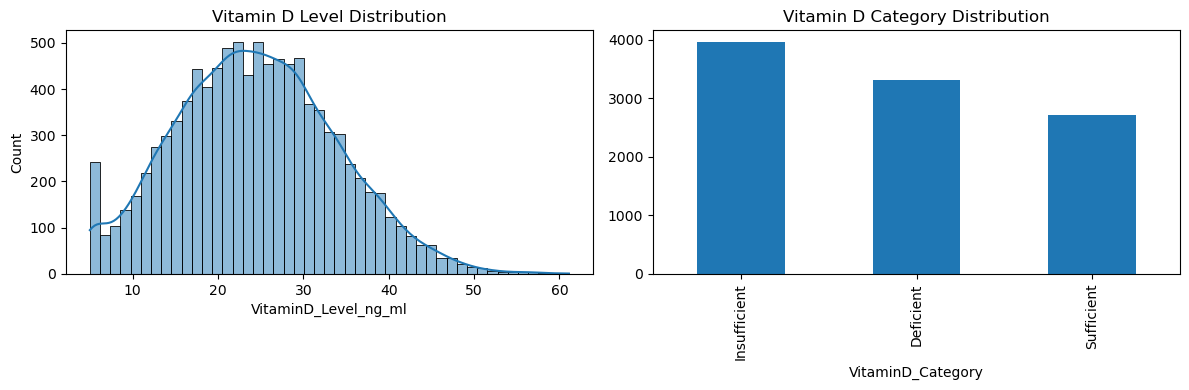

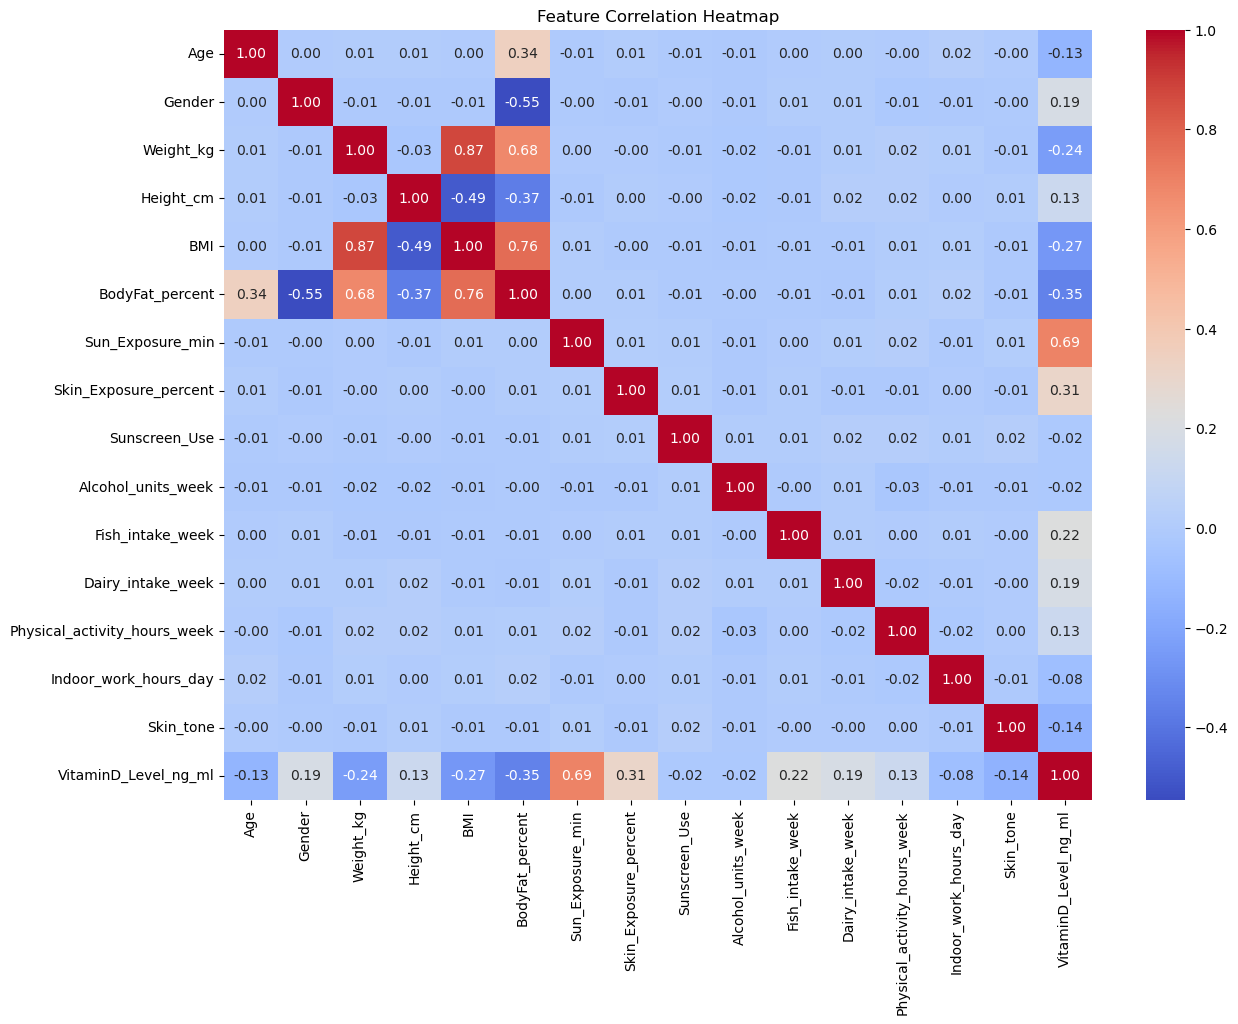

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("VitaminD_Dataset.csv")

# Check for missing values
print(df.isnull().sum())

# Visualize distribution of target variable
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['VitaminD_Level_ng_ml'], kde=True)
plt.title('Vitamin D Level Distribution')

plt.subplot(1, 2, 2)
df['VitaminD_Category'].value_counts().plot(kind='bar')
plt.title('Vitamin D Category Distribution')
plt.tight_layout()
plt.show()

# Check correlations (numeric columns only)
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [5]:
# Create additional features that might be useful
df['Sun_Exposure_Score'] = df['Sun_Exposure_min'] * (df['Skin_Exposure_percent'] / 100) * (1 - df['Sunscreen_Use'])
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 50], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 70], labels=['Young', 'Middle', 'Senior'])

# Check feature importance with target
print("\nCorrelation with Vitamin D Level:")

numeric_df = df.select_dtypes(include=[np.number])  # only numeric columns
print(numeric_df.corr()['VitaminD_Level_ng_ml'].sort_values(ascending=False))


Correlation with Vitamin D Level:
VitaminD_Level_ng_ml            1.000000
Sun_Exposure_min                0.692815
Sun_Exposure_Score              0.448106
Skin_Exposure_percent           0.311357
Fish_intake_week                0.222775
Dairy_intake_week               0.189283
Gender                          0.186667
Physical_activity_hours_week    0.128456
Height_cm                       0.126959
Alcohol_units_week             -0.015045
Sunscreen_Use                  -0.017500
Indoor_work_hours_day          -0.075743
Age                            -0.132071
Skin_tone                      -0.140962
Weight_kg                      -0.238475
BMI                            -0.267232
BodyFat_percent                -0.350948
Name: VitaminD_Level_ng_ml, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and target
X = df.drop(['VitaminD_Level_ng_ml', 'VitaminD_Category'], axis=1)
y_regression = df['VitaminD_Level_ng_ml']
y_classification = df['VitaminD_Category']

# Encode target (for classification use later)
le = LabelEncoder()
y_classification_encoded = le.fit_transform(y_classification)

# Convert categorical feature columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression Results
MAE : 3.204
MSE : 16.053
RMSE: 4.007
R2  : 0.813


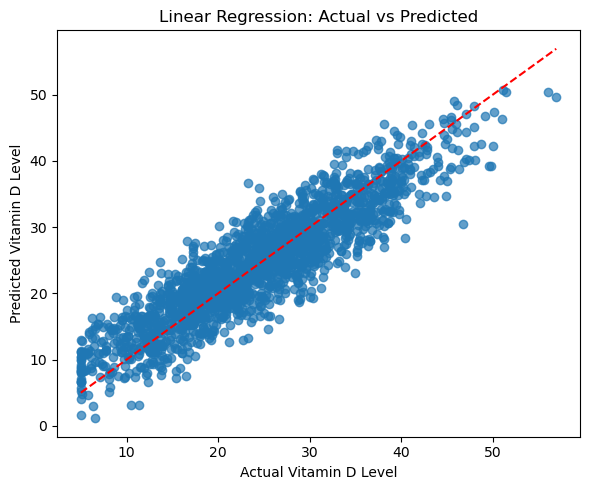

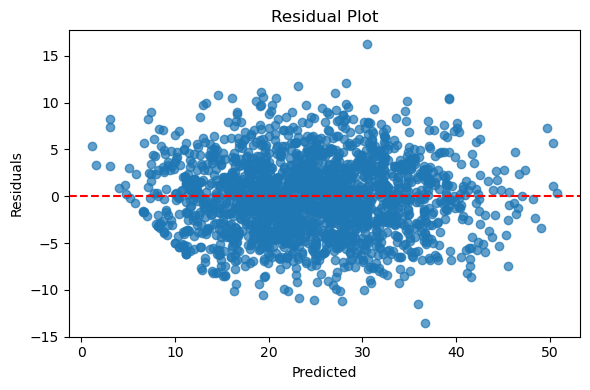


Top coefficients:
                         Feature  Coefficient
6               Sun_Exposure_min     6.423379
5                BodyFat_percent    -3.098102
7          Skin_Exposure_percent     2.868800
10              Fish_intake_week     1.992100
11             Dairy_intake_week     1.741244
14                     Skin_tone    -1.396913
12  Physical_activity_hours_week     1.198546
4                            BMI     0.725494
2                      Weight_kg    -0.678176
13         Indoor_work_hours_day    -0.632008
3                      Height_cm     0.369101
8                  Sunscreen_Use    -0.246881
0                            Age    -0.213755
18            BMI_Category_Obese    -0.144990
1                         Gender     0.095680

Saved: linear_regression_vitd.pkl, scaler_vitd.pkl, model_features_vitd.pkl


In [8]:
# Linear Regression model (regression only)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred = lr_model.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

# Actual vs Predicted plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Vitamin D Level")
plt.ylabel("Predicted Vitamin D Level")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

# Coefficients (feature impact)
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", key=np.abs, ascending=False)

print("\nTop coefficients:")
print(coef_df.head(15))

# Save model artifacts
joblib.dump(lr_model, "linear_regression_vitd.pkl")
joblib.dump(scaler, "scaler_vitd.pkl")
joblib.dump(X.columns.tolist(), "model_features_vitd.pkl")
print("\nSaved: linear_regression_vitd.pkl, scaler_vitd.pkl, model_features_vitd.pkl")

Deficiency Classification Results
ROC-AUC: 0.952

Classification Report:
              precision    recall  f1-score   support

           0      0.940     0.856     0.896      1343
           1      0.752     0.889     0.815       657

    accuracy                          0.867      2000
   macro avg      0.846     0.873     0.855      2000
weighted avg      0.878     0.867     0.869      2000



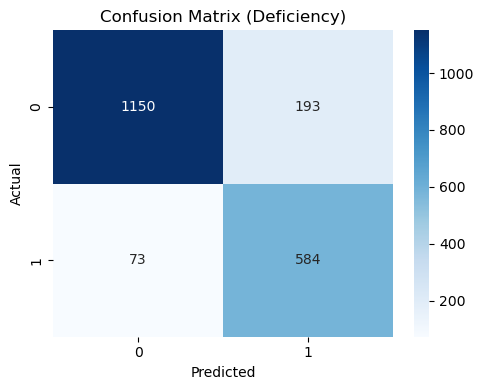

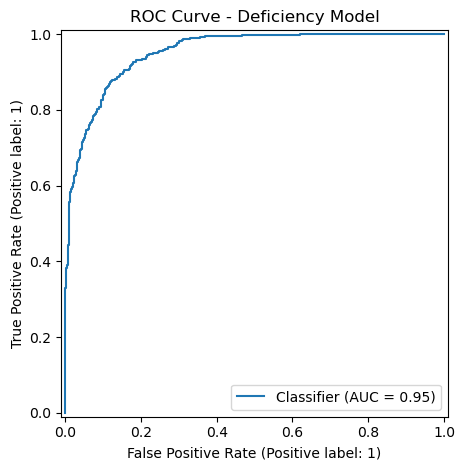


Saved deficiency model artifacts.


In [9]:
# Deficiency target + classification model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Clinical cutoff (common): deficient if Vitamin D < 20 ng/mL
DEFICIENCY_CUTOFF = 20.0
df["Deficient"] = (df["VitaminD_Level_ng_ml"] < DEFICIENCY_CUTOFF).astype(int)

# Features (same style as your regression pipeline)
X_cls = df.drop(["VitaminD_Level_ng_ml", "VitaminD_Category", "Deficient"], axis=1)
X_cls = pd.get_dummies(X_cls, drop_first=True)
y_cls = df["Deficient"]

# Train/test split (stratified for class balance)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Scale
scaler_cls = StandardScaler()
Xc_train_scaled = scaler_cls.fit_transform(Xc_train)
Xc_test_scaled = scaler_cls.transform(Xc_test)

# Logistic Regression
clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
clf.fit(Xc_train_scaled, yc_train)

# Predict probabilities + class (threshold can be tuned)
y_prob = clf.predict_proba(Xc_test_scaled)[:, 1]
THRESHOLD = 0.50
y_pred_cls = (y_prob >= THRESHOLD).astype(int)

# Metrics
print("Deficiency Classification Results")
print(f"ROC-AUC: {roc_auc_score(yc_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(yc_test, y_pred_cls, digits=3))

cm = confusion_matrix(yc_test, y_pred_cls)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Deficiency)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(yc_test, y_prob)
plt.title("ROC Curve - Deficiency Model")
plt.tight_layout()
plt.show()

# Save artifacts
joblib.dump(clf, "vitd_deficiency_logreg.pkl")
joblib.dump(scaler_cls, "vitd_deficiency_scaler.pkl")
joblib.dump(X_cls.columns.tolist(), "vitd_deficiency_features.pkl")
joblib.dump(THRESHOLD, "vitd_deficiency_threshold.pkl")
print("\nSaved deficiency model artifacts.")

In [10]:
# Inference helper: predict deficiency for one new person

import numpy as np
import pandas as pd
import joblib

clf = joblib.load("vitd_deficiency_logreg.pkl")
scaler_cls = joblib.load("vitd_deficiency_scaler.pkl")
model_features = joblib.load("vitd_deficiency_features.pkl")
THRESHOLD = joblib.load("vitd_deficiency_threshold.pkl")

def predict_deficiency(input_dict: dict):
    x_new = pd.DataFrame([input_dict])
    x_new = pd.get_dummies(x_new, drop_first=True)
    x_new = x_new.reindex(columns=model_features, fill_value=0)

    x_scaled = scaler_cls.transform(x_new)
    p_def = clf.predict_proba(x_scaled)[0, 1]
    pred = int(p_def >= THRESHOLD)

    return {
        "deficiency_probability": float(np.round(p_def, 4)),
        "predicted_class": "Deficient" if pred == 1 else "Not Deficient"
    }

# Example (edit values as needed)
sample = {
    "Age": 35,
    "BMI": 27.4,
    "Sun_Exposure_min": 20,
    "Skin_Exposure_percent": 30,
    "Sunscreen_Use": 1,
    "BodyFat_percent": 28,
    "Fish_intake_week": 1,
    "Dairy_intake_week": 3,
    "Physical_activity_hours_week": 2,
    "Indoor_work_hours_day": 9,
    "Skin_tone": 4,
    "Sun_Exposure_Score": 20 * (30 / 100) * (1 - 1),
    "BMI_Category": "Overweight",
    "Age_Group": "Middle"
}

print(predict_deficiency(sample))

{'deficiency_probability': 0.997, 'predicted_class': 'Deficient'}
